# Lorenz-96 demo

This notebook introduces the Lorenz-96 system and shows how to run it in Paleobeasts.
Lorenz-96 generalizes Lorenz-63 to *N* variables arranged on a periodic ring, making it a useful toy model
for multiscale dynamics and predictability experiments.

## How it differs from Lorenz-63

- **Dimension:** Lorenz-63 is 3D; Lorenz-96 is *N*-dimensional (often N=40).
- **Structure:** Lorenz-96 uses cyclic coupling on a ring: each variable interacts with its two neighbors.
- **Forcing:** Lorenz-96 is typically driven by a constant forcing term *F* (can be time-varying here).
- **Use case:** Lorenz-96 is a common testbed for data assimilation, predictability, and chaos in higher dimensions.

## How the Paleobeasts model API works

1. Create a `Forcing` object (optional for Lorenz-96 if you want time-varying F).
2. Instantiate the model.
3. Call `integrate(...)`.
4. Optionally reframe onto an evenly spaced time axis with `reframe_time_axis(...)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import paleobeasts as pb
from paleobeasts.signal_models import Lorenz96, Lorenz96TwoScale


In [2]:
# Common integration setup
t_span = (0.0, 30.0)
n = 10
y0 = np.ones(n)
t_eval = pb.utils.define_t_eval(t_span, delta_t=0.02)


## Unforced (constant F) Lorenz-96

Here we use the classic constant forcing term *F=8*.
In this implementation, if `forcing=None`, the model uses the constant `F` parameter.

In [3]:
lorenz_unforced = Lorenz96(forcing=None, n=n, F=8.0)
lorenz_unforced.integrate(t_span=t_span, y0=y0.tolist(), method='RK45')
lorenz_unforced.reframe_time_axis(t_eval, update_state=True)

t_u = lorenz_unforced.time
x0_u = lorenz_unforced.state_variables['x0']
x1_u = lorenz_unforced.state_variables['x1']


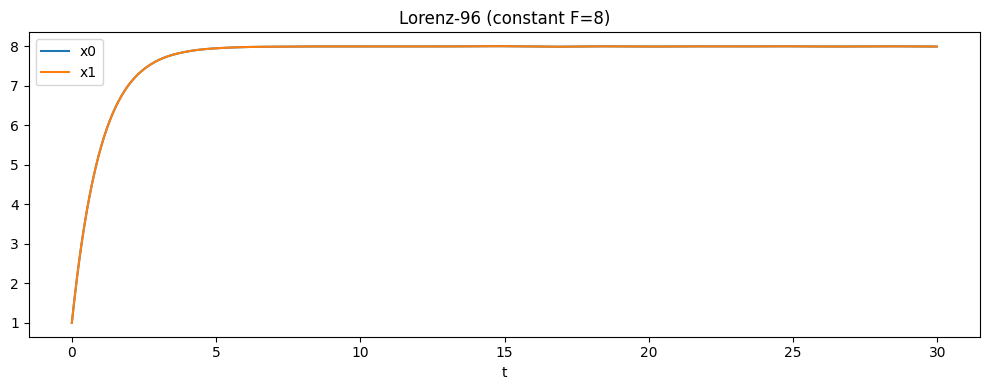

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(t_u, x0_u, label='x0')
plt.plot(t_u, x1_u, label='x1')
plt.title('Lorenz-96 (constant F=8)')
plt.xlabel('t')
plt.legend()
plt.tight_layout()


## Time-varying forcing

If you want to modulate the forcing, pass a `Forcing` object that returns `F(t)`.
Below we apply a gentle sinusoidal modulation around *F=8*.

In [5]:
def forcing_func(t):
    return 8.0 + 2.0 * np.sin(2 * np.pi * t / 10.0)

forcing = pb.core.Forcing(forcing_func)
lorenz_forced = Lorenz96(forcing=forcing, n=n, F=8.0)
lorenz_forced.integrate(t_span=t_span, y0=y0.tolist(), method='RK45')
lorenz_forced.reframe_time_axis(t_eval, update_state=True)

t_f = lorenz_forced.time
x0_f = lorenz_forced.state_variables['x0']
x1_f = lorenz_forced.state_variables['x1']


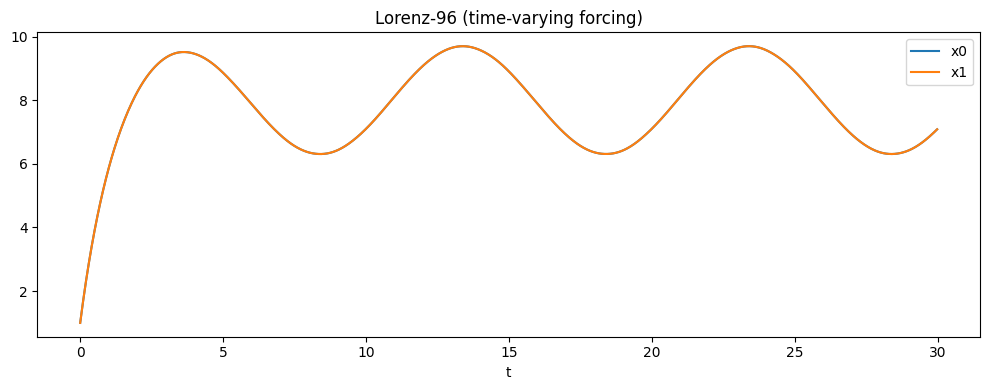

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(t_f, x0_f, label='x0')
plt.plot(t_f, x1_f, label='x1')
plt.title('Lorenz-96 (time-varying forcing)')
plt.xlabel('t')
plt.legend()
plt.tight_layout()


## Space-time visualization (forced case)

A common way to view Lorenz-96 dynamics is a space-time plot: each column is a state variable,
and each row is a time step. This highlights wave-like structures and traveling features.

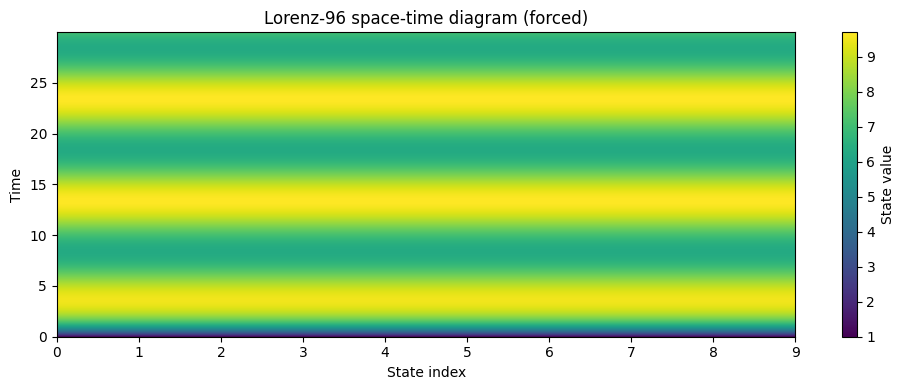

In [7]:
# Build a space-time matrix from the forced run
state_names = [f'x{i}' for i in range(n)]
X = np.column_stack([lorenz_forced.state_variables[name] for name in state_names])

plt.figure(figsize=(10, 4))
plt.imshow(X, aspect='auto', origin='lower', cmap='viridis',
           extent=[0, n - 1, t_f[0], t_f[-1]])
plt.colorbar(label='State value')
plt.title('Lorenz-96 space-time diagram (forced)')
plt.xlabel('State index')
plt.ylabel('Time')
plt.tight_layout()


## Notes and idiosyncrasies

- The state variables are named `x0, x1, ..., x{N-1}`.
- For high-dimensional runs (e.g., N=40), plotting a few coordinates is usually sufficient.
- Adaptive solvers (RK45) use uneven time steps; `reframe_time_axis(...)` gives you a uniform grid.

## Two-scale Lorenz-96

`Lorenz96TwoScale` adds a second, faster layer: each of the *K* slow variables $X_k$ is coupled to
*J* fast variables $Y_{k,j}$. The slow equation is identical to the single-scale case plus a coupling
term that drains energy to the fast layer; setting *J*=0 recovers the single-scale model exactly.

**Important:** use `method='l96_rk4'` with `kwargs={'dt': ..., 'si': ...}`. Adaptive solvers (RK45)
call `dydt` at intermediate sub-steps that corrupt the state history. Plain Euler is too coarse to
resolve the Y dynamics. `l96_rk4` runs a fixed-step RK4 internally at the Y timescale and samples
output at the coarser interval `si`.


In [ ]:
def s(k, K):
    """Non-dimensional coordinate in [-1, +1] for k = 0..K-1."""
    return 2 * (0.5 + k) / K - 1

K, J = 36, 10
nt, si, dt = 1000, 0.005, 0.005
F_2, h, b, c = 10.0, 1.0, 10.0, 10.0
t_span_2 = (0, nt * si)

k_idx = np.arange(K)
j_idx = np.arange(J * K)

X_init = s(k_idx, K) * (s(k_idx, K) - 1) * (s(k_idx, K) + 1)
Y_init = np.zeros(J * K)
y0_2 = np.concatenate([X_init, Y_init])

model_2 = Lorenz96TwoScale(K=K, J=J, F=F_2, h=h, b=b, c=c, exact_rhs=True)
model_2.integrate(t_span=t_span_2, y0=y0_2,
                  method='l96_rk4', kwargs={'dt': dt, 'si': si})

state_2 = model_2.state_variables
X_2 = np.column_stack([state_2[f'x{i}'] for i in range(K)])
Y_2 = np.column_stack([state_2[f'y{i}'] for i in range(K * J)])
t_2 = model_2.time


In [ ]:
plt.figure(figsize=(12, 10), dpi=150)

plt.subplot(221)
plt.plot(k_idx, X_2[-1], label="$X_k(t=n_t dt)$")
plt.plot(j_idx / J, Y_2[-1], label="$Y_{j,k}(t=n_t dt)$")
plt.plot(k_idx, X_init, "k:", label="$X_k(t=0)$")
plt.plot(j_idx / J, Y_init, "k:", label="$Y_{j,k}(t=0)$")
plt.legend(fontsize=7)
plt.xlabel("k, k + j/J")
plt.title("$X_k, Y_{j,k}$")

plt.subplot(222)
plt.plot(t_2, X_2[:, 0], label="$X_0(t)$")
plt.plot(t_2, Y_2[:, 0], label="$Y_{0,0}(t)$")
plt.legend(fontsize=7)
plt.xlabel("t")

plt.subplot(223)
plt.contourf(k_idx, t_2, X_2)
plt.colorbar(orientation="horizontal")
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$")

plt.subplot(224)
plt.contourf(j_idx / J, t_2, Y_2)
plt.colorbar(orientation="horizontal")
plt.xlabel("k + j/J")
plt.ylabel("t")
plt.title("$Y_{j,k}(t)$")

plt.tight_layout()
plt.show()
